# AI Architecture Integrity — Analysis Notebook

Visual exploration for `docs/methodology/analysis.md`'s five-stage analysis
plan. Every section below corresponds 1:1 to a numbered subsection of that
document — read it first for the *why* behind each chart; this notebook is
the *what the data actually shows*.

**Data flow**: `src/ingest.py` parses raw experiment artifacts
(`reports/experiments/**/*.json`, `reports/baseline/*.json`,
`session_manifest.yaml`) into `data/*.csv`. Each `src/stages/s*.py` script
reads those CSVs (never the raw JSON) and writes its derived result to
`data/derived/*.csv`. This notebook only reads `data/` and `data/derived/`
and only draws charts — it recomputes nothing itself.

Run the regeneration cell below whenever `reports/experiments/` has new
runs; otherwise skip straight to Stage 0.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ANALYSIS_DIR = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(ANALYSIS_DIR / "src"))

from paths import DATA_DIR, DERIVED_DIR  # noqa: E402
import charts  # noqa: E402

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## Regenerate `data/` and `data/derived/` (optional)

Set `REGENERATE = True` and run this cell after new experiment sessions
land under `reports/experiments/`. This calls `src/update_all.py` — the
same orchestrator the command line uses (`python3 src/update_all.py`) — so
there's exactly one place that knows the stage dependency order, not one
copy here and another in that script.

In [2]:
REGENERATE = False

if REGENERATE:
    import subprocess

    result = subprocess.run(
        [sys.executable, str(ANALYSIS_DIR / "src" / "update_all.py")],
        cwd=ANALYSIS_DIR, capture_output=True, text=True,
    )
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("update_all.py failed — see output above")

---
## §2.0 Run-Level Overview

Read this table first, before anything else. One row per `(agent,
strategy, task)`: did the agent finish per protocol, did the Harness
evaluation complete, how many constraint violations did this task step
introduce/resolve on its own (`run_local`), and the cumulative net-new
violation count since baseline (`trajectory_cumulative`) alongside the
literal current violation count in the code. Every later chart is a
zoomed-in slice of this table.

In [3]:
overview = pd.read_csv(DERIVED_DIR / "run_overview.csv")
display(overview)

incomplete = overview.loc[~(overview["task_completed"] & overview["harness_completed"])]
if not incomplete.empty:
    print("Rows not fully completed (exclude or footnote these before aggregating):")
    display(incomplete[["session_id", "task_id", "task_completed", "harness_completed"]])
else:
    print("Every run in this dataset finished per protocol and was fully evaluated.")

,session_id,agent,strategy,task_id,task_completed,harness_completed,constraints_introduced_this_task,constraints_resolved_this_task,cumulative_net_new_violations,current_absolute_violations
0,session_20260817_130253,claude,minimal,T1,True,True,11,0,11,16
1,session_20260817_130253,claude,minimal,T2,True,True,9,9,12,16
2,session_20260817_130253,claude,minimal,T3,True,True,2,5,9,13
3,session_20260817_160757,claude,structured,T1,True,True,9,0,9,14
4,session_20260817_160757,claude,structured,T2,True,True,8,8,10,14
5,session_20260817_160757,claude,structured,T3,True,True,4,5,9,13
6,session_20260817_210911,codex,minimal,T1,True,True,12,0,12,17
7,session_20260817_210911,codex,minimal,T2,True,True,31,9,35,39
8,session_20260817_210911,codex,minimal,T3,True,True,15,16,34,38
9,session_20260817_221755,codex,structured,T1,True,True,11,0,11,16


Every run in this dataset finished per protocol and was fully evaluated.


### §2.0b Violations by scope (backend / frontend / cross-stack)

Same `(agent, strategy, task)` rows as the table above, but splitting
`current_absolute_violations` by where the finding actually lives instead
of collapsing it into one total. `cross_findings_absolute` counts findings
from cross-stack scopes (e.g. API contract checks that inspect both sides
at once).

In [4]:
scope_breakdown = pd.read_csv(DERIVED_DIR / "run_scope_breakdown.csv")
display(scope_breakdown)

if (scope_breakdown["cross_findings_absolute"] == 0).all():
    print("No cross-stack findings in this dataset yet — every violation so far is "
          "attributable to a single side (backend or frontend).")

,session_id,agent,strategy,task_id,backend_findings_absolute,frontend_findings_absolute,cross_findings_absolute,total_findings_absolute
0,session_20260817_130253,claude,minimal,T1,8,8,0,16
1,session_20260817_130253,claude,minimal,T2,5,11,0,16
2,session_20260817_130253,claude,minimal,T3,2,11,0,13
3,session_20260817_160757,claude,structured,T1,7,7,0,14
4,session_20260817_160757,claude,structured,T2,6,8,0,14
5,session_20260817_160757,claude,structured,T3,5,8,0,13
6,session_20260817_210911,codex,minimal,T1,8,9,0,17
7,session_20260817_210911,codex,minimal,T2,29,10,0,39
8,session_20260817_210911,codex,minimal,T3,27,11,0,38
9,session_20260817_221755,codex,structured,T1,7,9,0,16


No cross-stack findings in this dataset yet — every violation so far is attributable to a single side (backend or frontend).


### §2.0c Concern-level violation profile (19 concerns, unmerged)

Two follow-up aggregations on top of §2.0b's layer totals, at the full
19-concern granularity from Appendix A / Table 3.2 (backend: 9, frontend:
7, cross-stack: 3) instead of §3.1's collapsed 7-category heatmap — every
concern gets a row even if it never fired, and same-named categories are
*not* merged across scopes (`BE-DUP` and `FE-DUP` stay two different
rows), because both questions below depend on keeping that distinction:

1. **Which concerns absorb the bulk of violations?** Basis is
   `deltas.trajectory_cumulative` "introduced" (net-new since baseline),
   averaged across each agent's 6 evaluations (2 strategies × 3 tasks) —
   see `s0_4_concern_profile.py`'s docstring for why cumulative-then-mean
   rather than a raw sum.
2. **Does backend carry more than frontend, and what happened at
   cross-stack?** `concern_layer_summary.csv` rolls the 19 rows up to
   their three layers.

`cross-stack` is the standout: it recorded **zero** net-new findings
across all 12 evaluations. That is stated here as a plain descriptive fact
about this dataset; *why* — agents genuinely kept the two stacks in sync,
or the 3 cross-stack rules are not sensitive enough to catch what they are
meant to catch — is a discussion-chapter question, taken up in Chapter 5.

In [5]:
concern_profile = pd.read_csv(DERIVED_DIR / "concern_profile.csv")
layer_summary = pd.read_csv(DERIVED_DIR / "concern_layer_summary.csv")

print("Concern profile, canonical order (Appendix A / Table 3.2 -- backend, then frontend, then cross-stack):")
display(concern_profile)

ranked = concern_profile.sort_values("combined_mean_per_eval", ascending=False)
print("\nSame rows, ranked by combined mean net-new violations per evaluation:")
display(ranked[["concern", "layer", "combined_mean_per_eval", "share_of_total_pct"]])

n_zero = int((concern_profile["combined_mean_per_eval"] == 0).sum())
top3_share = ranked["share_of_total_pct"].head(3).sum()
print(f"\n{n_zero}/19 concerns never recorded a net-new violation in this dataset; "
      f"the top 3 concerns alone ({', '.join(ranked['concern'].head(3))}) "
      f"account for {top3_share:.1f}% of the combined violation load.")

print("\nRolled up by layer:")
display(layer_summary)

Concern profile, canonical order (Appendix A / Table 3.2 -- backend, then frontend, then cross-stack):


,concern,layer,display_label,claude_mean_per_eval,codex_mean_per_eval,combined_mean_per_eval,share_of_total_pct
0,BE-STRUCT,backend,BE-STRUCT,0.000000,0.000000,0.000000,0.000000
1,BE-DEP,backend,BE-DEP,0.666667,0.000000,0.333333,2.020202
2,BE-DOM,backend,BE-DOM,0.500000,1.000000,0.750000,4.545455
3,BE-ERR,backend,BE-ERR,0.000000,10.333333,5.166667,31.313131
4,BE-CONTRACT,backend,BE-CONTRACT,3.000000,4.166667,3.583333,21.717172
5,BE-ROUTE,backend,BE-ROUTE,0.000000,0.000000,0.000000,0.000000
6,BE-SIZE,backend,BE-SIZE,0.166667,0.000000,0.083333,0.505051
7,BE-DUP,backend,BE-DUP,1.166667,2.333333,1.750000,10.606061
8,BE-TEST,backend,BE-TEST,0.000000,0.000000,0.000000,0.000000
9,FE-COM,frontend,FE-COM,0.833333,0.500000,0.666667,4.040404



Same rows, ranked by combined mean net-new violations per evaluation:


,concern,layer,combined_mean_per_eval,share_of_total_pct
3,BE-ERR,backend,5.166667,31.313131
15,FE-DUP,frontend,4.166667,25.252525
4,BE-CONTRACT,backend,3.583333,21.717172
7,BE-DUP,backend,1.750000,10.606061
2,BE-DOM,backend,0.750000,4.545455
9,FE-COM,frontend,0.666667,4.040404
1,BE-DEP,backend,0.333333,2.020202
6,BE-SIZE,backend,0.083333,0.505051
13,FE-DATA,frontend,0.000000,0.000000
17,CROSS-TYPE,cross-stack,0.000000,0.000000



11/19 concerns never recorded a net-new violation in this dataset; the top 3 concerns alone (BE-ERR, FE-DUP, BE-CONTRACT) account for 78.3% of the combined violation load.

Rolled up by layer:


,layer,n_concerns,n_concerns_with_findings,total_mean_per_eval,share_of_total_pct
0,backend,9,6,11.666667,70.707071
1,frontend,7,2,4.833333,29.292929
2,cross-stack,3,0,0.000000,0.000000


### §2.0d Concern profile chart (backend → frontend → cross-stack)

Same nineteen rows as the table above, plotted as grouped bars (Claude vs
Codex) in fixed backend → frontend → cross-stack order, with a shaded
band and divider line at each layer boundary so the three blocks read as
blocks rather than one undifferentiated row of 19 bars.

The y-axis is linear and un-truncated — truncating a bar chart's axis to
"zoom in" on the small bars would distort the height comparison, which is
the one thing this chart must stay honest about. That means it can only
show *shape* (which concerns are a live problem, which are not); read the
table above for exact values, especially the small non-zero bars
(0.08–1.75) that a chart scaled to fit BE-ERR's 5.17 will compress almost
to the baseline. Chart and table are doing two different jobs on purpose.

X-axis text comes from `concern_profile.csv`'s `display_label` column,
itself populated from the `CONCERN_DISPLAY_LABELS` mapping at the top of
`src/stages/s0_4_concern_profile.py` — edit that dict (not this notebook)
to relabel a concern on the axis; rerun that stage script to regenerate
the CSV the chart reads.

In [6]:
import importlib

importlib.reload(charts)

<module 'charts' from '/Users/luowei/project/ai-architecture-integrity-study/reports/analysis/src/charts.py'>

<Axes: title={'center': 'Mean Net-New Violations per Evaluation, by Concern\n(Backend,Frontend,Cross-Stack)'}, xlabel='Concern (grouped by layer)', ylabel='Mean net-new violations per evaluation\n(trajectory_cumulative, introduced)'>

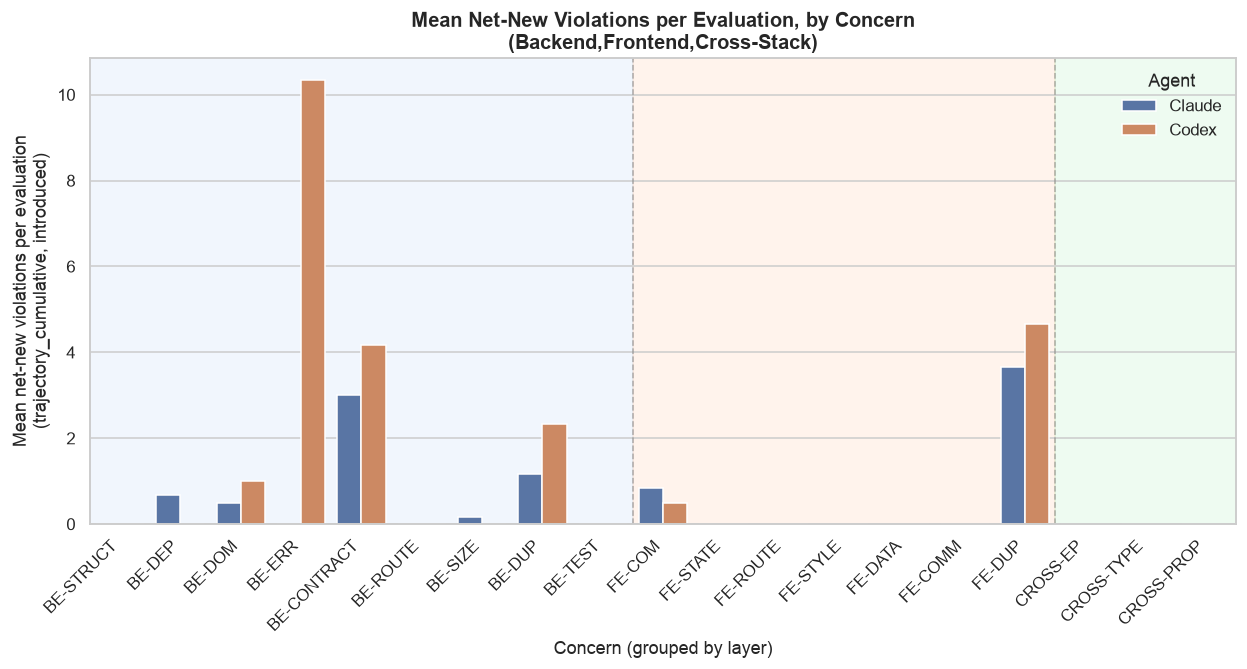

In [7]:
agent_cols = [
    c for c in concern_profile.columns
    if c.endswith("_mean_per_eval") and c != "combined_mean_per_eval"
]
agent_names = {c: c.removesuffix("_mean_per_eval").capitalize() for c in agent_cols}

concern_long = concern_profile.melt(
    id_vars=["concern", "layer", "display_label"],
    value_vars=agent_cols,
    var_name="agent_col",
    value_name="mean_net_new_violations",
)
concern_long["Agent"] = concern_long["agent_col"].map(agent_names)

concern_order = concern_profile["display_label"].tolist()
charts.grouped_bar_with_group_bands(
    concern_long,
    x="display_label", y="mean_net_new_violations", hue="Agent",
    group_col="layer", order=concern_order,
    title="Mean Net-New Violations per Evaluation, by Concern\n(Backend,Frontend,Cross-Stack)",
    xlabel="Concern (grouped by layer)",
    ylabel="Mean net-new violations per evaluation\n(trajectory_cumulative, introduced)",
    legend_title="Agent",
)

### §2.0e Minimal vs Structured — a first look

A slope chart straight off §2.0's own `constraints_introduced_this_task`
column (`run_local`, i.e. what this task step alone introduced) — six
lines, one per `(agent, task)` pair, each running from its Minimal value to
its Structured value:

| Agent | Task | Minimal | Structured | Direction |
|---|---|---|---|---|
| Claude | T1 | 11 | 9  | ↓ −2 |
| Claude | T2 | 9  | 8  | ↓ −1 |
| Claude | T3 | 2  | 4  | ↑ +2 (the one reversal) |
| Codex  | T1 | 12 | 11 | ↓ −1 |
| Codex  | T2 | 31 | 23 | ↓ −8 (largest drop) |
| Codex  | T3 | 15 | 13 | ↓ −2 |

X-axis is the two-position ordered pair (Minimal, Structured), not a
continuous axis; Y-axis is the raw introduced-violation count (2–31). This
is the same pairing and the same underlying `run_local_introduced_count`
values as §4.1 below (`strategy_comparison_pairs.csv`) — placed here too
as an early visual next to the run-level numbers it's drawn from. The
paired significance test (Wilcoxon) and the full discussion belong to
§4.1; this cell is the picture only.

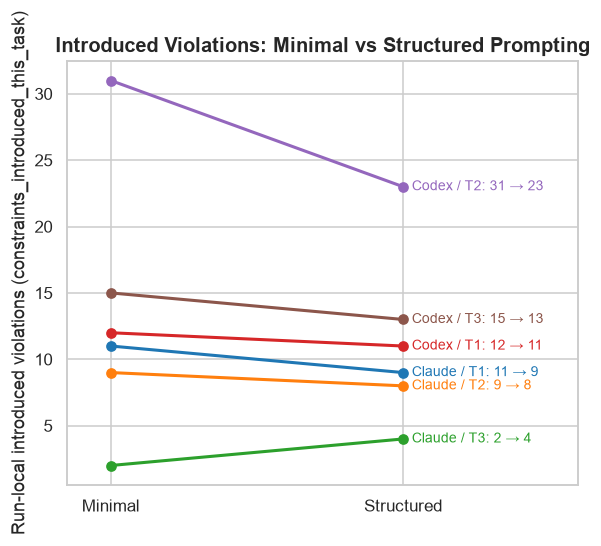

In [8]:
early_pairs = pd.read_csv(DERIVED_DIR / "strategy_comparison_pairs.csv")

if {"minimal", "structured"}.issubset(early_pairs.columns) and not early_pairs.empty:
    early_pairs = early_pairs.copy()
    early_pairs["label"] = early_pairs["agent"].str.capitalize() + " / " + early_pairs["task_id"]
    charts.slope_chart(
        early_pairs, left_col="minimal", right_col="structured", label_col="label",
        title="Introduced Violations: Minimal vs Structured Prompting",
        left_label="Minimal", right_label="Structured",
        ylabel="Run-local introduced violations (constraints_introduced_this_task)",
    )
else:
    print("Not enough paired (minimal, structured) runs yet.")

### §2.0f Which rules drove the Minimal → Structured change

§2.0e's six line segments each collapse a task's whole rule-level story
into one net number. This breaks each segment back out to the specific
`rule_id`s (not the concern rollup used elsewhere) that fired under
Minimal and/or Structured, so a −2 or −8 can be read as "these rules,
specifically" instead of an unexplained total. Basis is the same
`run_local` "introduced" delta as §2.0e; `s0_5_strategy_rule_diff.py`
self-checks that every pair's rule-level diffs sum back to the exact net
change §2.0e's chart already shows.

In [9]:
import json

rule_diff = pd.read_csv(DERIVED_DIR / "strategy_rule_diff.csv")
rule_diff_check = json.loads((DERIVED_DIR / "strategy_rule_diff_self_check.json").read_text())
print(f"Rule-level diffs reconcile with §2.0e's per-pair totals: {rule_diff_check['passes_self_check']}")

pair_totals = early_pairs.set_index(["agent", "task_id"])[["minimal", "structured"]]


def short_rule(rule_id: str) -> str:
    """BE-DUP-C-003-no-equivalent-production-code -> BE-DUP-C-003"""
    return "-".join(rule_id.split("-", 4)[:4])


print("\nPer-pair rule breakdown (sorted by |diff|, largest first):")
for (agent, task_id), group in rule_diff.groupby(["agent", "task_id"], sort=False):
    minimal_total, structured_total = pair_totals.loc[(agent, task_id)]
    net = structured_total - minimal_total
    ordered = group.loc[group["diff"].abs().sort_values(ascending=False).index]
    detail = ", ".join(f"{row.diff:+g} {short_rule(row.rule_id)}" for row in ordered.itertuples())
    print(f"  {agent.capitalize()} / {task_id}  ({minimal_total:g} -> {structured_total:g}, {net:+g}):  {detail}")

appeared_or_grew = rule_diff.loc[rule_diff["diff"] > 0].groupby("rule_id").size().sort_values(ascending=False)
shrank_or_disappeared = rule_diff.loc[rule_diff["diff"] < 0].groupby("rule_id").size().sort_values(ascending=False)

print("\nRules that increased under Structured, by how many of the 6 pairs:")
display(appeared_or_grew.rename("n_pairs_increased").reset_index())

print("\nRules that decreased under Structured, by how many of the 6 pairs:")
display(shrank_or_disappeared.rename("n_pairs_decreased").reset_index())

top_up = appeared_or_grew.index[0]
print(f"\n{short_rule(top_up)} ({top_up.split('-', 4)[-1]}) increased under Structured in "
      f"{appeared_or_grew.iloc[0]}/6 pairs — the single most consistent rule-level movement "
      "in either direction, and it runs opposite to the overall Structured-is-fewer pattern: "
      "it is a partial offset baked into every pair's net number above, not a one-off.")

Rule-level diffs reconcile with §2.0e's per-pair totals: True

Per-pair rule breakdown (sorted by |diff|, largest first):
  Claude / T1  (11 -> 9, -2):  -1 BE-CONTRACT-C-001, -1 BE-DOM-C-001, -1 FE-DUP-C-002, +1 BE-DUP-C-003
  Claude / T2  (9 -> 8, -1):  -3 BE-CONTRACT-C-001, +3 BE-DUP-C-003, +2 BE-DEP-C-004, -1 BE-DOM-C-001, -1 FE-COM-C-001, -1 FE-DUP-C-002
  Claude / T3  (2 -> 4, +2):  +3 BE-DUP-C-003, -1 BE-SIZE-C-001, -1 FE-COM-C-001, +1 FE-DUP-C-001
  Codex / T1  (12 -> 11, -1):  +3 BE-ERR-C-002, -2 BE-CONTRACT-C-001, -2 BE-DOM-C-001, +0 FE-DUP-C-002
  Codex / T2  (31 -> 23, -8):  -9 BE-ERR-C-002, -1 BE-DOM-C-001, -1 FE-COM-C-001, +1 BE-CONTRACT-C-001, +1 BE-DUP-C-002, +1 BE-DUP-C-003, +0 FE-DUP-C-002
  Codex / T3  (15 -> 13, -2):  -4 BE-ERR-C-002, +3 BE-DUP-C-003, -2 FE-COM-C-001, +1 BE-DUP-C-002, +0 FE-DUP-C-002

Rules that increased under Structured, by how many of the 6 pairs:


,rule_id,n_pairs_increased
0,BE-DUP-C-003-no-equivalent-production-code,5
1,BE-DUP-C-002-single-policy-implementation,2
2,BE-CONTRACT-C-001-entity-change-requires-migra...,1
3,BE-DEP-C-004-no-circular-dependencies,1
4,BE-ERR-C-002-throw-only-app-exception,1
5,FE-DUP-C-001-single-resource-owner,1



Rules that decreased under Structured, by how many of the 6 pairs:


,rule_id,n_pairs_decreased
0,BE-DOM-C-001-no-cross-module-deep-import,4
1,FE-COM-C-001-component-file-max-lines,4
2,BE-CONTRACT-C-001-entity-change-requires-migra...,3
3,BE-ERR-C-002-throw-only-app-exception,2
4,FE-DUP-C-002-single-authoritative-implementation,2
5,BE-SIZE-C-001-max-method-parameters,1



BE-DUP-C-003 (no-equivalent-production-code) increased under Structured in 5/6 pairs — the single most consistent rule-level movement in either direction, and it runs opposite to the overall Structured-is-fewer pattern: it is a partial offset baked into every pair's net number above, not a one-off.


---
## Stage 0 — Data Quality & Baseline Calibration

Before reading any result below: is this batch of data trustworthy?

### §2.1 Harness reliability

Which metrics come back `status: "error"` most often, and which runs have a
scope-level failure? Both are tool problems, not architecture findings —
they should be excluded from (or footnoted in) every later chart.

In [10]:
error_rates = pd.read_csv(DERIVED_DIR / "metric_error_rates.csv")
reliability = pd.read_csv(DERIVED_DIR / "run_reliability.csv")

flaky = error_rates[error_rates["error_rate"] > 0].sort_values("error_rate", ascending=False)
if not flaky.empty:
    charts.grouped_bar(
        flaky,
        x="metric_name",
        y="error_rate",
        title="Metric Error Rate Across All Runs",
        xlabel="Metric",
        ylabel="Share of runs with status=error",
    )
else:
    print("No metric ever returned status=error in this dataset.")

display(reliability.loc[~reliability["is_reliable"]])

No metric ever returned status=error in this dataset.


,evaluation_id,session_id,task_id,agent,strategy,execution_status,comparison_status,backend_status,frontend_status,cross_status,scope_errors,metric_errors,metric_coverage,is_reliable


### §2.2 Pre-existing debt subtraction (net-new violations)

Baseline's own violations must not be credited to the agent. The
baseline-vs-baseline self-check should always read `True` — it validates
that the delta pipeline itself has no bug.

In [11]:
import json

debt_table = pd.read_csv(DERIVED_DIR / "baseline_debt_by_category.csv")
self_check = json.loads((DERIVED_DIR / "baseline_self_check.json").read_text())

print(f"Baseline self-check passes: {self_check['passes_self_check']}")
display(debt_table)

Baseline self-check passes: True


,category,baseline_absolute_count,avg_agent_absolute_count,avg_trajectory_net_new
0,ERR,0.0,12.400,12.400000
1,DUP,3.0,8.250,5.916667
2,CONTRACT,0.0,5.375,5.375000
3,DEP,0.0,2.000,2.000000
4,COM,0.0,1.600,1.600000
5,DOM,0.0,1.500,1.500000
6,SIZE,0.0,1.000,1.000000
7,STATE,2.0,2.000,0.000000


### §2.3 Task completion gate

`harness_evaluation.json` says nothing about whether the agent finished
cleanly or whether the feature it built passed acceptance tests. `fail` is
a real functional gap (not an architecture data problem); `error` means the
acceptance *infrastructure* didn't run and should be treated like a tool
failure, same as §2.1.

Every agent run in this dataset finished per protocol.


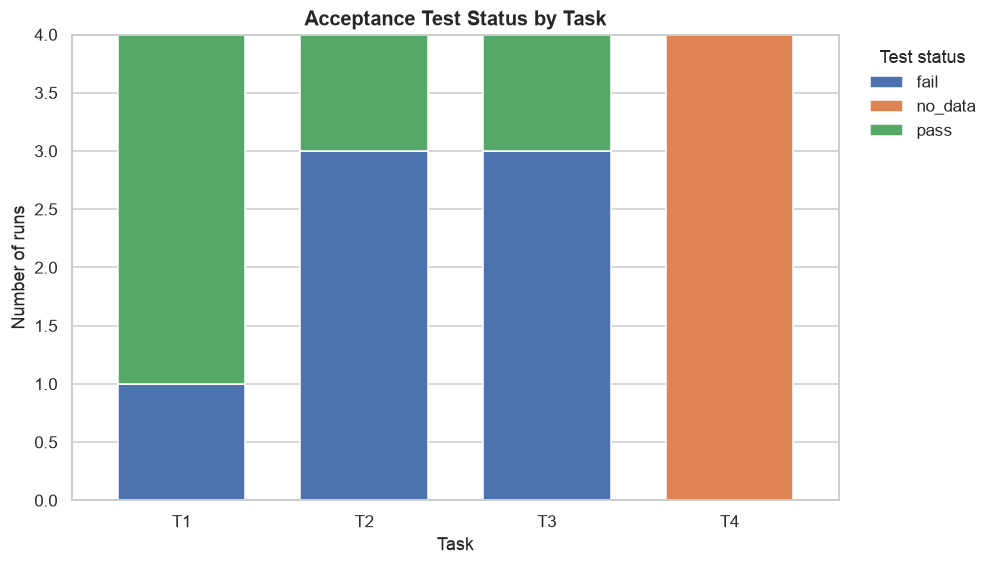

In [12]:
completion = pd.read_csv(DERIVED_DIR / "task_completion_gate.csv")

status_by_task = (
    completion.groupby(["task_id", "test_status"]).size().unstack(fill_value=0)
)
charts.stacked_bar(
    status_by_task,
    title="Acceptance Test Status by Task",
    xlabel="Task",
    ylabel="Number of runs",
    legend_title="Test status",
)

flagged = completion.loc[completion["flagged_for_review"]]
if not flagged.empty:
    print("Runs flagged for review (agent did not finish cleanly):")
    display(flagged)
else:
    print("Every agent run in this dataset finished per protocol.")

---
## Stage 1 — Descriptive Overview

No condition splits yet — where do violations concentrate overall?

### §3.1 Violation heatmap (agent × category)

Net-new (`run_local`) violations per run, averaged within each agent, one
column per rule category.

<Axes: title={'center': 'Mean Net-New Violations per Run by Agent and Category'}, xlabel='Rule category', ylabel='Agent'>

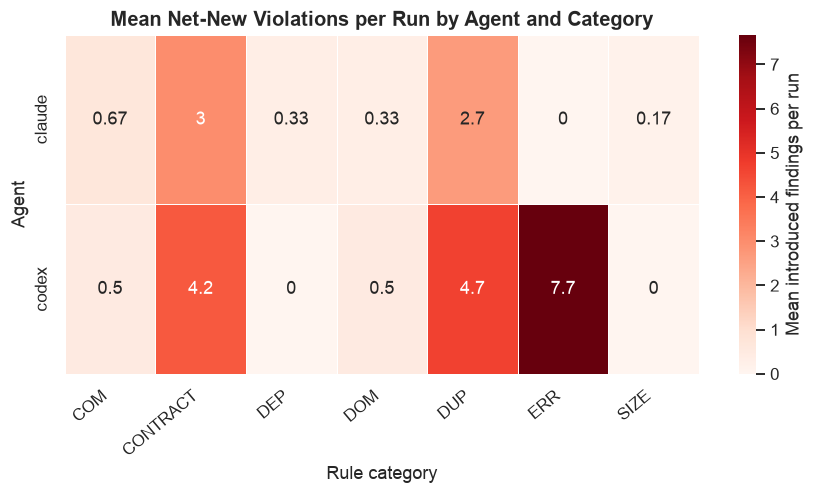

In [13]:
violation_matrix = pd.read_csv(DERIVED_DIR / "violation_rate_matrix.csv", index_col=0)
charts.heatmap(
    violation_matrix.values,
    row_labels=list(violation_matrix.index),
    col_labels=list(violation_matrix.columns),
    title="Mean Net-New Violations per Run by Agent and Category",
    cbar_label="Mean introduced findings per run",
    xlabel="Rule category",
    ylabel="Agent",
)

### §3.2 Metric distribution overview

Bounded metrics (ratio/percent, roughly 0–1) and unbounded metrics (counts,
levels, params, props) are plotted separately since they don't share a
scale.

<Axes: title={'center': 'Unbounded Metric Distributions (count / levels / params / props)'}, xlabel='Metric', ylabel='Value'>

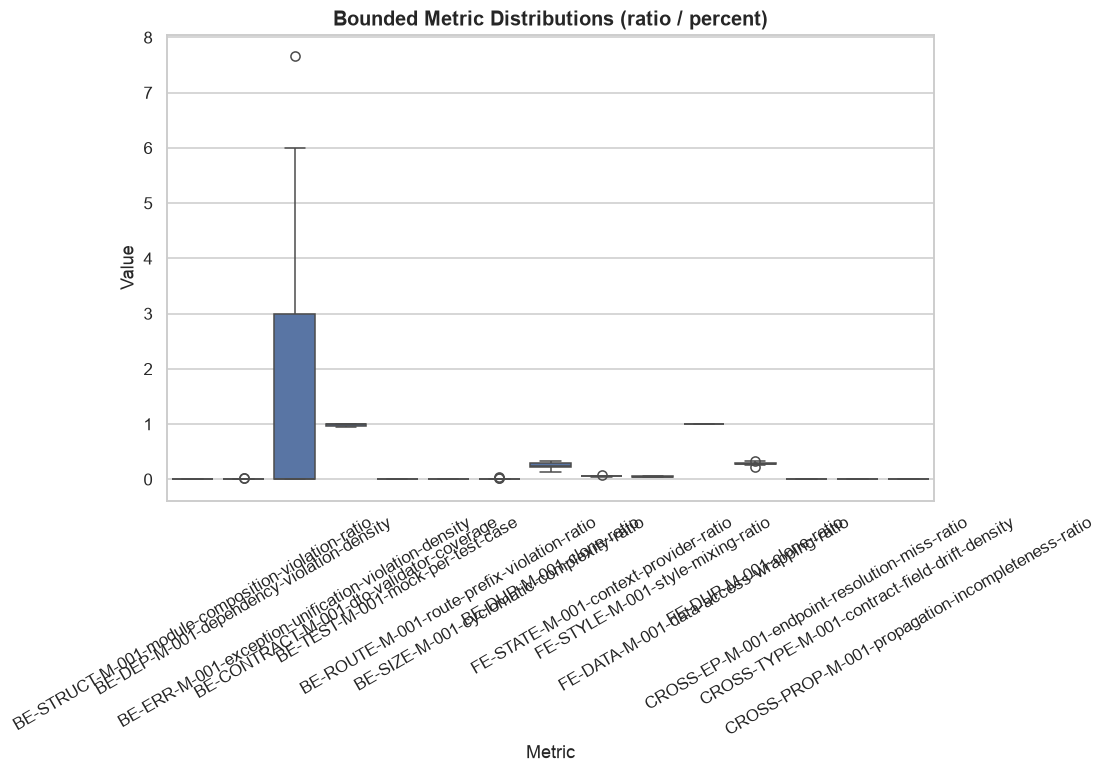

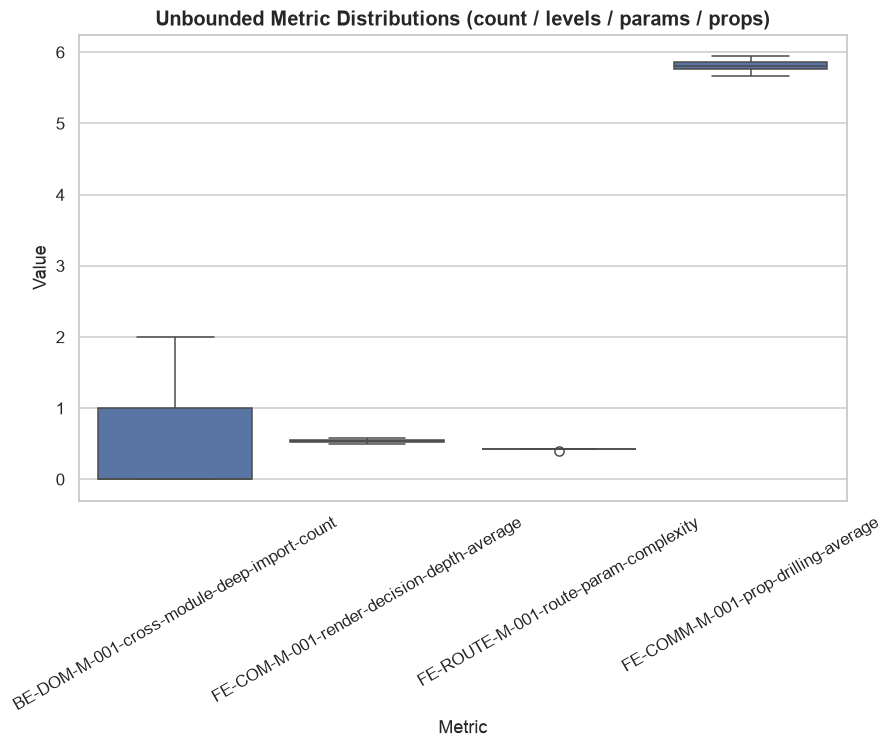

In [14]:
metric_observations = pd.read_csv(DATA_DIR / "metric_observations.csv").dropna(subset=["value"])
bounded_units = {"ratio", "percent"}
bounded = metric_observations[metric_observations["unit"].isin(bounded_units)]
unbounded = metric_observations[~metric_observations["unit"].isin(bounded_units)]

charts.box_or_violin(
    bounded, x="metric_name", y="value",
    title="Bounded Metric Distributions (ratio / percent)",
    xlabel="Metric", ylabel="Value",
)
charts.box_or_violin(
    unbounded, x="metric_name", y="value",
    title="Unbounded Metric Distributions (count / levels / params / props)",
    xlabel="Metric", ylabel="Value",
)

---
## Stage 2 — Cross-Condition Comparison

### §4.1 Prompt strategy comparison (minimal vs structured)

Paired per `(agent, task)`. A downward-sloping line means `structured`
introduced fewer net-new violations than `minimal` for that pair.

{
  "claude": {
    "n_pairs": 3,
    "statistic": 2.5,
    "p_value": 1.0,
    "median_diff": -1.0,
    "note": null
  },
  "codex": {
    "n_pairs": 3,
    "statistic": 0.0,
    "p_value": 0.25,
    "median_diff": -2.0,
    "note": null
  },
  "overall": {
    "n_pairs": 6,
    "statistic": 4.0,
    "p_value": 0.21875,
    "median_diff": -1.5,
    "note": null
  }
}


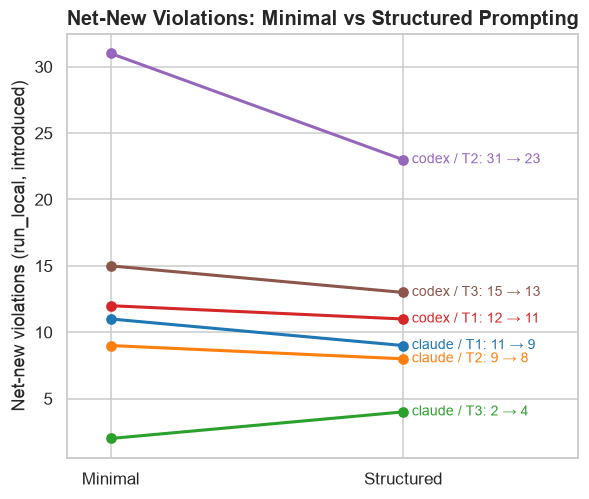

In [15]:
pairs = pd.read_csv(DERIVED_DIR / "strategy_comparison_pairs.csv")
strategy_tests = json.loads((DERIVED_DIR / "strategy_comparison_test.json").read_text())

if {"minimal", "structured"}.issubset(pairs.columns) and not pairs.empty:
    pairs["label"] = pairs["agent"] + " / " + pairs["task_id"]
    charts.slope_chart(
        pairs, left_col="minimal", right_col="structured", label_col="label",
        title="Net-New Violations: Minimal vs Structured Prompting",
        left_label="Minimal", right_label="Structured",
        ylabel="Net-new violations (run_local, introduced)",
    )
else:
    print("Not enough paired (minimal, structured) runs yet.")

print(json.dumps(strategy_tests, indent=2))

### §4.2 Agent "architecture personality"

Same matrix as §3.1, one polygon per agent — compare *shape*, not just
overall size.

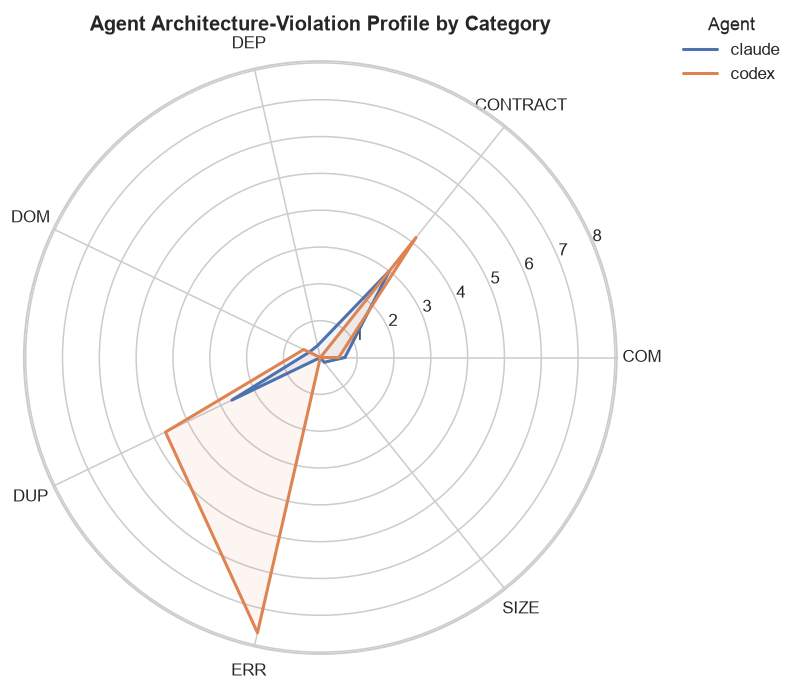

In [16]:
profile_matrix = pd.read_csv(DERIVED_DIR / "agent_profile_matrix.csv", index_col=0)
if len(profile_matrix) >= 1:
    charts.radar(
        categories=list(profile_matrix.columns),
        series={agent: row.tolist() for agent, row in profile_matrix.iterrows()},
        title="Agent Architecture-Violation Profile by Category",
        legend_title="Agent",
    )

---
## Stage 3 — Longitudinal Trend

### §5.1 Trajectory curve shape

`trajectory_cumulative` net-new violations, relative to the *original*
baseline, across the task sequence for each `agent × strategy` condition.

,agent,strategy,n_points,final_trajectory_introduced_count,shape
0,claude,minimal,3,9,plateau_or_decline
1,claude,structured,3,9,plateau_or_decline
2,codex,minimal,3,34,plateau_or_decline
3,codex,structured,3,20,plateau_or_decline


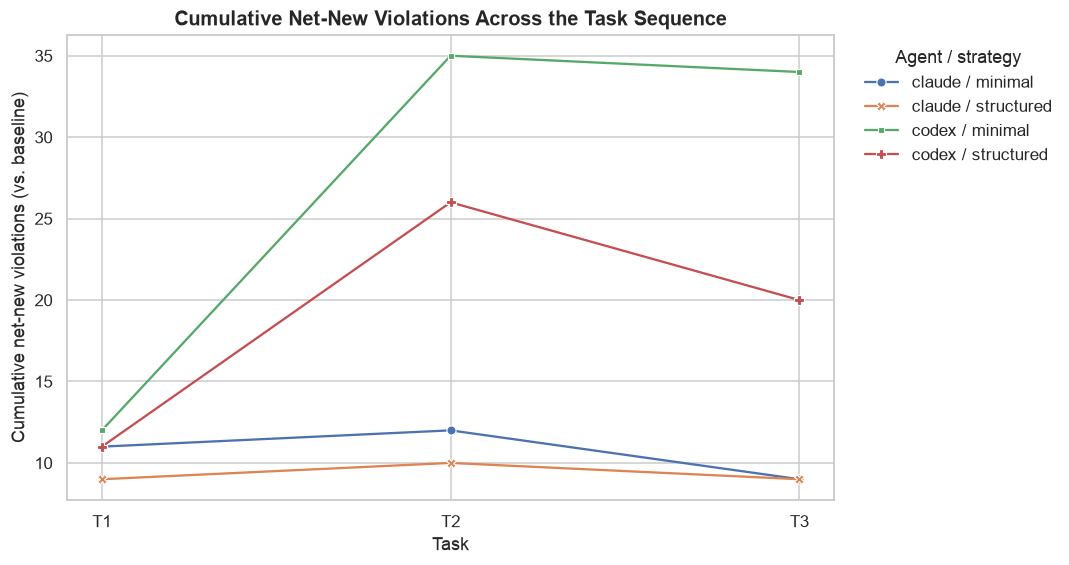

In [17]:
totals = pd.read_csv(DERIVED_DIR / "trajectory_totals.csv")
shapes = pd.read_csv(DERIVED_DIR / "trajectory_shapes.csv")

totals["condition"] = totals["agent"] + " / " + totals["strategy"]
charts.line_trajectory(
    totals, x="task_id", y="trajectory_introduced_count", hue="condition",
    title="Cumulative Net-New Violations Across the Task Sequence",
    xlabel="Task", ylabel="Cumulative net-new violations (vs. baseline)",
    legend_title="Agent / strategy",
)
display(shapes)

### §5.1b Absolute violation count across the same task sequence

The chart above is *net-new relative to the original baseline*
(`trajectory_cumulative`, resolved violations subtracted out). This is a
different question on the same four conditions and the same T1→T3 x-axis:
**as of this task, how many violations does the code actually have right
now** — baseline's pre-existing debt plus everything introduced minus
whatever has since been resolved, i.e. the literal count sitting in the
codebase at that checkpoint. That is `current_absolute_violations`, the
same column §2.0's run-level overview table already carries (`runs.csv`'s
`total_findings_absolute` — see [ingest.py](../src/ingest.py)'s
`build_run_record`, and the raw `after_count` field walked through above)
— no new computation, just the same four conditions re-plotted on this
column instead.

,agent,strategy,task_id,current_absolute_violations
0,claude,minimal,T1,16
1,claude,minimal,T2,16
2,claude,minimal,T3,13
3,claude,structured,T1,14
4,claude,structured,T2,14
5,claude,structured,T3,13
6,codex,minimal,T1,17
7,codex,minimal,T2,39
8,codex,minimal,T3,38
9,codex,structured,T1,16


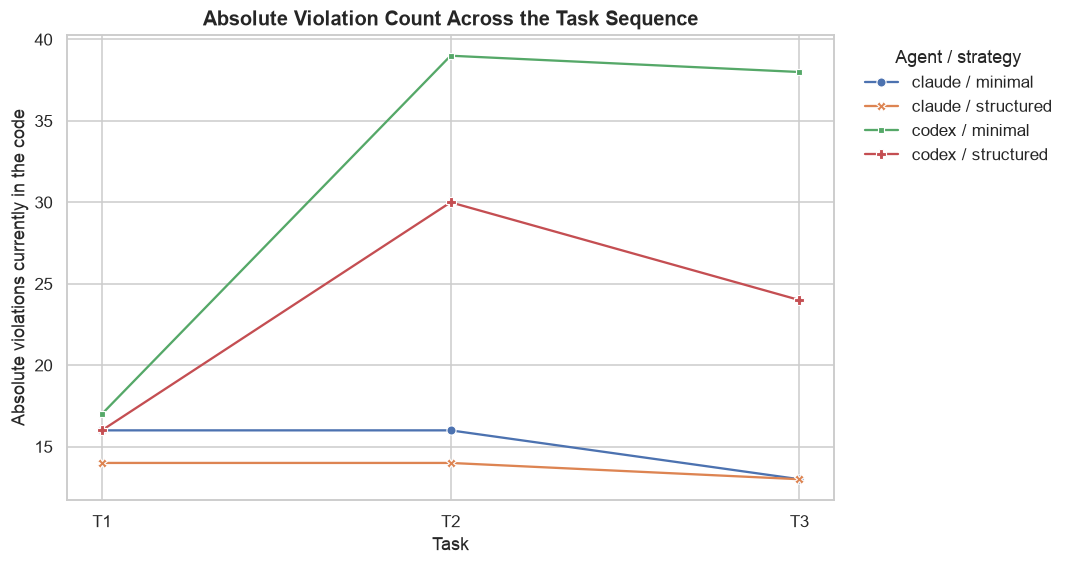

In [18]:
absolute_totals = pd.read_csv(DERIVED_DIR / "run_overview.csv")
absolute_totals["condition"] = absolute_totals["agent"] + " / " + absolute_totals["strategy"]

charts.line_trajectory(
    absolute_totals, x="task_id", y="current_absolute_violations", hue="condition",
    title="Absolute Violation Count Across the Task Sequence",
    xlabel="Task", ylabel="Absolute violations currently in the code",
    legend_title="Agent / strategy",
)
display(
    absolute_totals[["agent", "strategy", "task_id", "current_absolute_violations"]]
    .sort_values(["agent", "strategy", "task_id"])
    .reset_index(drop=True)
)

---
## Stage 4 — Deep Mechanism Mining

### §6.1 Silent decay

Evaluations where a **concern's own binary constraint** passes but that
**same concern's own continuous metric** is already a "bad" outlier by
§3.2's IQR fence — the case that motivates having a `metrics` layer at
all, not just `constraints`. Each of the 19 concerns (Appendix A / Table
3.2) has its own constraint rule(s) *and* its own representative metric
covering the same ground (e.g. `BE-SIZE-C-001`'s parameter-count check
alongside `BE-SIZE-M-001`'s cyclomatic-complexity metric), so "silent" is
evaluated at that grain — one concern at a time — not "did the whole run
pass all 36 rules across all 19 concerns before any metric gets a say".

An earlier version of this cell asked the run-wide question first: with
constraint failure defined per *run* (any of 36 rules, any concern) and
checked before any metric, and every run in this dataset failing *some*
rule, every evaluation got swept into `constraints_failed` regardless of
what its metrics showed — including 4 of the 12 runs where a metric from
an *unrelated* concern to whichever rule failed was independently a
bad-side outlier. Scoping both sides of the comparison to the same
concern (`s4_1_silent_decay.py`, now one row per (evaluation, concern) —
228 rows) removes that masking; the results below are what that
re-scoped comparison actually finds.

3 silent-decay cells, spanning 3/12 evaluations:


,evaluation_id,agent,strategy,task_id,concern,metric_name,metric_value
25,session_20260817_130253/T2,claude,minimal,T2,BE-SIZE,BE-SIZE-M-001-cyclomatic-complexity-ratio,0.023810
96,session_20260817_160757/T3,claude,structured,T3,BE-DEP,BE-DEP-M-001-dependency-violation-density,0.020202
158,session_20260817_210911/T3,codex,minimal,T3,BE-SIZE,BE-SIZE-M-001-cyclomatic-complexity-ratio,0.015152



Per-evaluation summary (each row = 19 concerns classified; 'clean' kept here for completeness):


,agent,strategy,task_id,clean,silent_decay,constraints_failed,indeterminate_metric_error,any_silent_decay,silent_decay_concerns
0,claude,minimal,T1,16,0,3,0,False,
1,claude,minimal,T2,14,1,4,0,True,BE-SIZE
2,claude,minimal,T3,17,0,2,0,False,
3,claude,structured,T1,16,0,3,0,False,
4,claude,structured,T2,14,0,5,0,False,
5,claude,structured,T3,16,1,2,0,True,BE-DEP
6,codex,minimal,T1,16,0,3,0,False,
7,codex,minimal,T2,13,0,6,0,False,
8,codex,minimal,T3,14,1,4,0,True,BE-SIZE
9,codex,structured,T1,16,0,3,0,False,


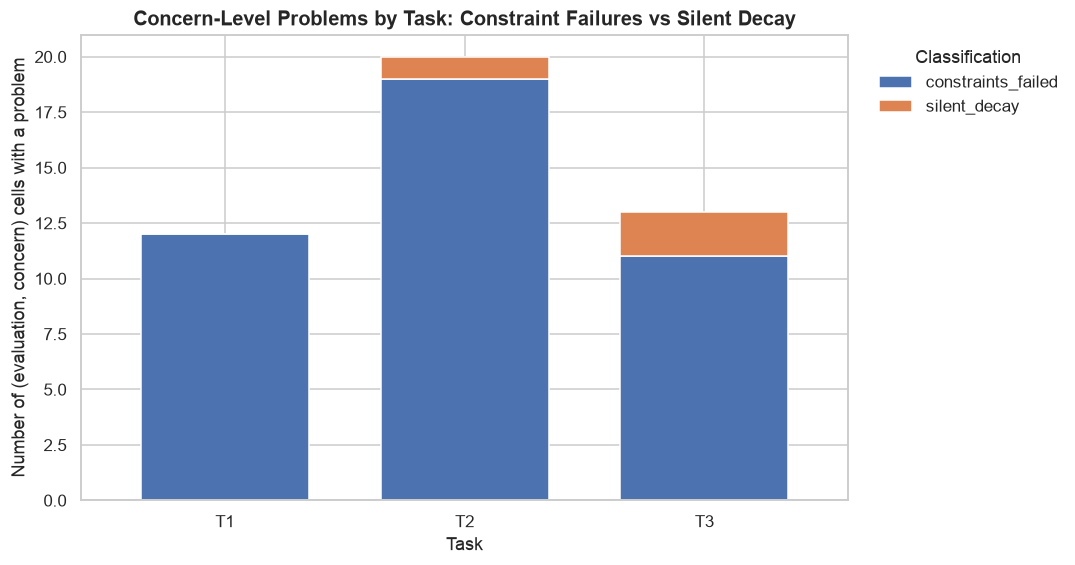

In [19]:
by_concern = pd.read_csv(DERIVED_DIR / "silent_decay_by_concern.csv")
run_summary = pd.read_csv(DERIVED_DIR / "silent_decay_run_summary.csv")
order = ["clean", "silent_decay", "constraints_failed", "indeterminate_metric_error"]

by_task = (
    by_concern.groupby(["task_id", "classification"]).size().unstack(fill_value=0)
    .reindex(columns=order, fill_value=0)
)

# "clean" is the large majority by construction (most concerns pass most of
# the time) and isn't the comparison this section is about; dropping it lets
# the chart's scale show the actual question -- of the concerns that *do*
# have a problem, how many were caught by the binary gate (constraints_failed)
# vs only visible in the metric (silent_decay). Full counts including clean
# are still in by_task/run_summary below for anyone who wants them.
problem_order = ["constraints_failed", "silent_decay"]
by_task_problems = by_task[problem_order]

charts.stacked_bar(
    by_task_problems,
    title="Concern-Level Problems by Task: Constraint Failures vs Silent Decay",
    xlabel="Task", ylabel="Number of (evaluation, concern) cells with a problem",
    legend_title="Classification",
)

n_indeterminate = int(by_task["indeterminate_metric_error"].sum())
if n_indeterminate:
    print(f"({n_indeterminate} (evaluation, concern) cells were indeterminate_metric_error "
          "and are excluded from the chart above.)")

silent = by_concern.loc[by_concern["classification"] == "silent_decay"]
if not silent.empty:
    n_evals = int(run_summary["any_silent_decay"].sum())
    print(f"{len(silent)} silent-decay cells, spanning {n_evals}/{len(run_summary)} evaluations:")
    display(silent[["evaluation_id", "agent", "strategy", "task_id", "concern", "metric_name", "metric_value"]])
else:
    print("No silent-decay cells in this dataset.")

print("\nPer-evaluation summary (each row = 19 concerns classified; 'clean' kept here for completeness):")
display(
    run_summary[[
        "agent", "strategy", "task_id", "clean", "silent_decay", "constraints_failed",
        "indeterminate_metric_error", "any_silent_decay", "silent_decay_concerns",
    ]].assign(silent_decay_concerns=lambda d: d["silent_decay_concerns"].fillna(""))
)

#### §6.1's raw metric values, not just the flagged cells

The `silent_decay` label above is a binary in/outside-the-IQR-fence call —
it says nothing about *how far* a value sits from the fence, and nothing
about the cells that never crossed it either. This table is the full
underlying signal: every concern's representative metric's raw value at
every `(agent, strategy, task)` checkpoint, so a concern that isn't
flagged can still be read as "trending toward the fence" rather than just
"clean" — the same magnitude-vs-binary-label gap discussed above.

In [20]:
concern_order_list = pd.read_csv(DERIVED_DIR / "concern_profile.csv")["concern"].tolist()
condition_order = [
    f"{agent.capitalize()}/{strategy.capitalize()} {task}"
    for agent in ["claude", "codex"]
    for strategy in ["minimal", "structured"]
    for task in ["T1", "T2", "T3"]
]

metric_table = by_concern.assign(
    condition=lambda d: d["agent"].str.capitalize() + "/" + d["strategy"].str.capitalize() + " " + d["task_id"]
)

# direction is constant per concern (one representative metric each) -- take
# it once per concern rather than repeating the merge per condition column.
direction_by_concern = (
    metric_table.drop_duplicates("concern").set_index("concern")["direction"].reindex(concern_order_list)
)
direction_label = direction_by_concern.map({
    "higher_is_better": "higher is better", "lower_is_better": "lower is better",
}).fillna("n/a")

metric_wide = (
    metric_table.pivot(index="concern", columns="condition", values="metric_value")
    .reindex(index=concern_order_list, columns=condition_order)
)
metric_wide.insert(0, "direction", direction_label)

n_never_nonzero = int(metric_wide[condition_order].fillna(0).eq(0).all(axis=1).sum())
print(f"Raw metric value at every (agent, strategy, task) checkpoint, all 19 concerns "
      f"({n_never_nonzero}/19 never leave 0 across all 12 evaluations). 'direction' says which way "
      "is good for that concern's own metric -- 'lower is better' concerns turning up in the bad_outliers "
      "table below crossed the fence by going too high; 'higher is better' ones by dropping too low:")
display(metric_wide.round(4))

bad_outliers = (
    metric_table.loc[metric_table["metric_bad_outlier"]]
    .assign(direction=lambda d: d["concern"].map(direction_label))
    [["condition", "concern", "direction", "metric_value", "constraint_failed", "classification"]]
    .sort_values(["concern", "condition"])
    .reset_index(drop=True)
)
print(f"\n{len(bad_outliers)} cells above actually crossed the IQR fence (some end up 'silent_decay', "
      "others 'constraints_failed' -- if constraint_failed is also True for that same concern, the "
      "fence-crossing isn't silent, it coincides with a same-concern constraint violation):")
display(bad_outliers)

Raw metric value at every (agent, strategy, task) checkpoint, all 19 concerns (6/19 never leave 0 across all 12 evaluations). 'direction' says which way is good for that concern's own metric -- 'lower is better' concerns turning up in the bad_outliers table below crossed the fence by going too high; 'higher is better' ones by dropping too low:


condition,direction,Claude/Minimal T1,Claude/Minimal T2,Claude/Minimal T3,Claude/Structured T1,Claude/Structured T2,Claude/Structured T3,Codex/Minimal T1,Codex/Minimal T2,Codex/Minimal T3,Codex/Structured T1,Codex/Structured T2,Codex/Structured T3
concern,,,,,,,,,,,,,
BE-STRUCT,lower is better,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
BE-DEP,lower is better,0.0000,0.0000,0.0000,0.0000,0.0208,0.0202,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
BE-DOM,lower is better,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,2.0000,2.0000,0.0000,0.0000,0.0000
BE-ERR,lower is better,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6.0000,7.6667,1.0000,3.0000,3.0000
BE-CONTRACT,higher is better,1.0000,1.0000,1.0000,1.0000,0.9464,0.9474,1.0000,0.9565,0.9574,1.0000,1.0000,1.0000
BE-ROUTE,lower is better,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
BE-SIZE,lower is better,0.0000,0.0238,0.0444,0.0000,0.0000,0.0000,0.0000,0.0000,0.0152,0.0000,0.0000,0.0000
BE-DUP,lower is better,0.2714,0.3206,0.3232,0.2280,0.3076,0.2968,0.2709,0.2198,0.1870,0.1858,0.2484,0.2382
BE-TEST,lower is better,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000



7 cells above actually crossed the IQR fence (some end up 'silent_decay', others 'constraints_failed' -- if constraint_failed is also True for that same concern, the fence-crossing isn't silent, it coincides with a same-concern constraint violation):


,condition,concern,direction,metric_value,constraint_failed,classification
0,Claude/Structured T2,BE-DEP,lower is better,0.020833,True,constraints_failed
1,Claude/Structured T3,BE-DEP,lower is better,0.020202,False,silent_decay
2,Codex/Minimal T3,BE-ERR,lower is better,7.666667,True,constraints_failed
3,Claude/Minimal T2,BE-SIZE,lower is better,0.023810,False,silent_decay
4,Claude/Minimal T3,BE-SIZE,lower is better,0.044444,True,constraints_failed
5,Codex/Minimal T3,BE-SIZE,lower is better,0.015152,False,silent_decay
6,Codex/Minimal T1,FE-DUP,lower is better,0.337728,True,constraints_failed


### §6.2 Violation spatial distribution (concentrated vs diffuse)

Gini coefficient of net-new findings across touched files, one bar per run
(higher = more concentrated in a handful of files), plus a Lorenz curve for
the single most concentrated run as a worked example. The table below rolls
the same per-file counts up across all evaluations, to answer a different
question than the chart above: not "how concentrated was this one run",
but "which files keep showing up across runs" — the ones worth aiming a
targeted code review at.

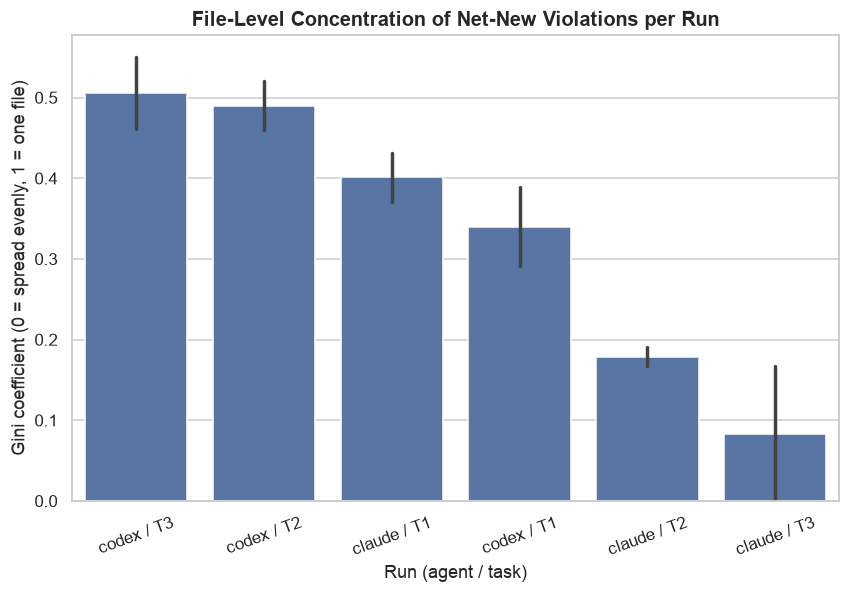

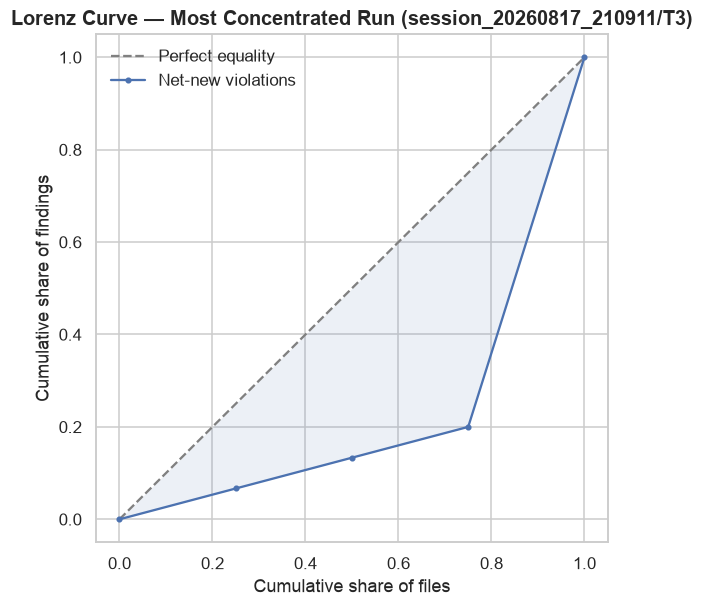

In [21]:
concentration = pd.read_csv(DERIVED_DIR / "file_concentration.csv")
concentration["label"] = concentration["agent"] + " / " + concentration["task_id"]
charts.grouped_bar(
    concentration.sort_values("gini_coefficient", ascending=False),
    x="label", y="gini_coefficient",
    title="File-Level Concentration of Net-New Violations per Run",
    xlabel="Run (agent / task)", ylabel="Gini coefficient (0 = spread evenly, 1 = one file)",
)

if not concentration.empty:
    most_concentrated = concentration.sort_values("gini_coefficient", ascending=False).iloc[0]
    constraint_findings = pd.read_csv(DATA_DIR / "constraint_findings.csv")
    example = constraint_findings[
        (constraint_findings["evaluation_id"] == most_concentrated["evaluation_id"])
        & (constraint_findings["delta_scope"] == "run_local")
        & (constraint_findings["change_type"] == "introduced")
    ]
    file_counts = example.groupby("file").size()
    charts.lorenz_curve(
        file_counts.values,
        title=f"Lorenz Curve — Most Concentrated Run ({most_concentrated['evaluation_id']})",
        series_label="Net-new violations",
    )

In [22]:
blame_summary = pd.read_csv(DERIVED_DIR / "file_blame_summary.csv")
display(blame_summary)

,file,n_findings_total,share_of_total_pct,n_evaluations_present,n_evaluations_as_top_file
0,backend/src/modules/deal/deal.service.ts,51,34.459459,11,5
1,backend/src/modules/deal/deal.entity.ts,23,15.540541,4,4
2,backend/src/modules/contact/contact.service.ts,16,10.810811,2,1
3,backend/src/modules/contact/contact.entity.ts,9,6.081081,2,0
4,frontend/src/pages/deals/dealQueries.js,8,5.405405,4,0
5,backend/src/modules/deal/deal-contact-link.ent...,6,4.054054,3,1
6,frontend/src/pages/deals/DealForm.jsx,5,3.378378,5,0
7,frontend/src/pages/contacts/ContactTable.jsx,4,2.702703,4,0
8,frontend/src/pages/deals/DealTable.jsx,4,2.702703,4,0
9,backend/src/modules/deal/deal-contact.entity.ts,3,2.027027,1,1


### §6.3 Metric correlation structure

Are the ~19 continuous metrics independent signals, or do several measure
the same underlying thing? PCA is attempted with complete-case runs only —
skipped in the printed log if there aren't enough of them yet.

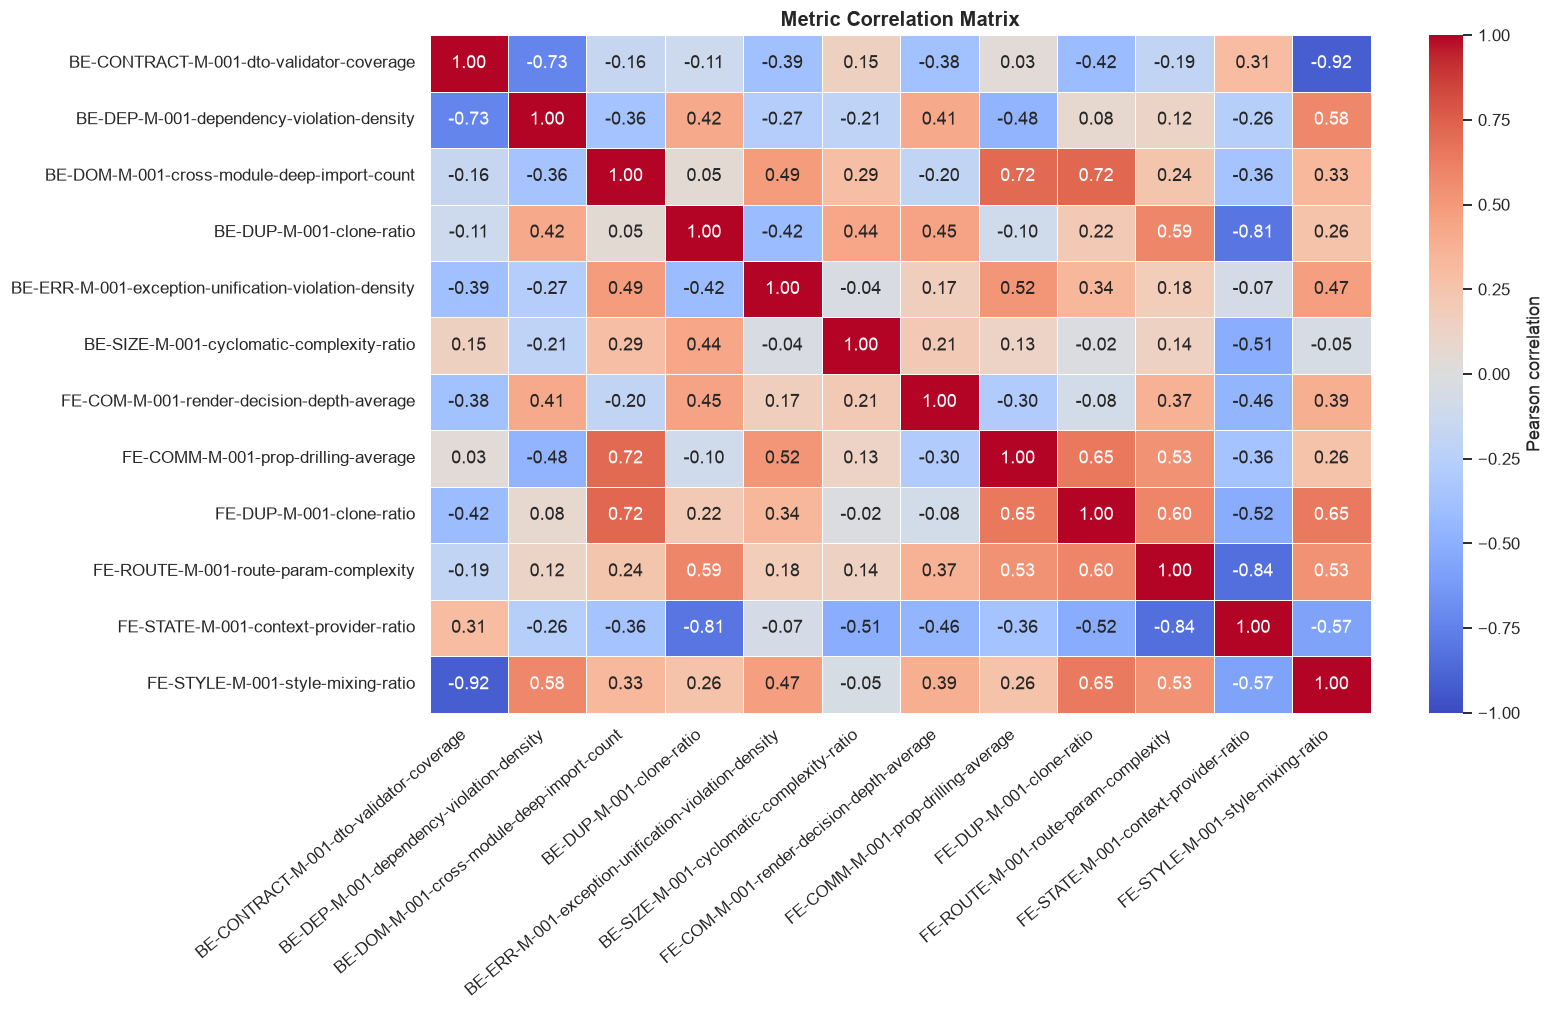

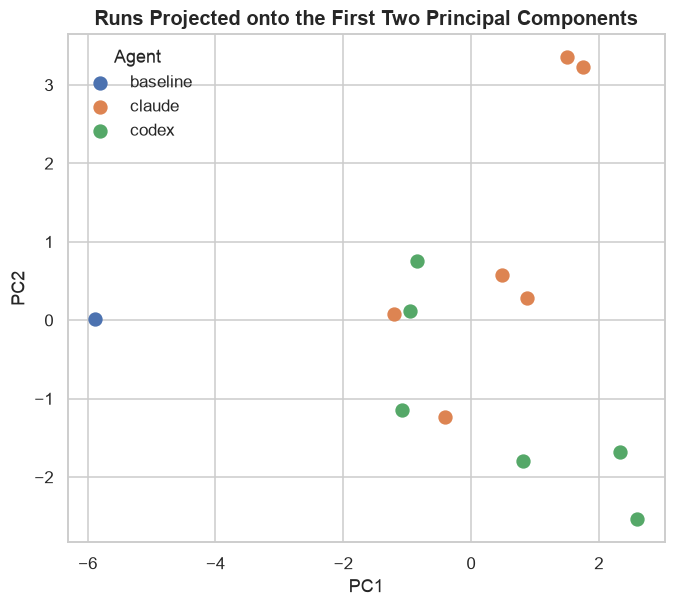

In [23]:
correlation = pd.read_csv(DERIVED_DIR / "metric_correlation.csv", index_col=0)
charts.corr_heatmap(correlation, title="Metric Correlation Matrix")

pca_scores_path = DERIVED_DIR / "metric_pca_scores.csv"
if pca_scores_path.exists():
    pca_scores = pd.read_csv(pca_scores_path, index_col=0)
    pca_scores = pca_scores.join(
        pd.read_csv(DATA_DIR / "runs.csv").set_index("evaluation_id")[["agent", "strategy"]]
    )
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(7, 6))
    for agent, group in pca_scores.groupby("agent"):
        ax.scatter(group["PC1"], group["PC2"], label=agent, s=70)
    ax.set_title("Runs Projected onto the First Two Principal Components")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(title="Agent", frameon=False)
else:
    print("PCA not available yet — see s4_3_metric_correlation.py's printed log for why.")

**Full variance spectrum.** The PC1/PC2 scatter above only shows the
first two components, so a PC1 share that isn't dominant could still
hide a small effective dimensionality further down the spectrum. The
scree plot below plots every component's explained-variance share (bars)
and the running cumulative total (line) — how many components it
actually takes to account for most of the variance is the more direct
answer to "are these metrics redundant" than PC1 alone.

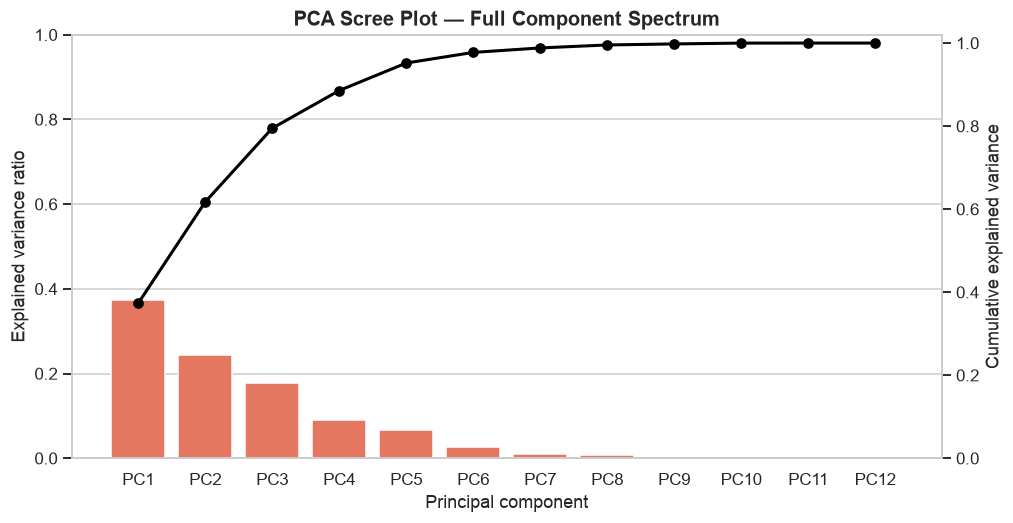

In [24]:
pca_variance_path = DERIVED_DIR / "metric_pca_variance.csv"
if pca_variance_path.exists():
    pca_variance = pd.read_csv(pca_variance_path)
    charts.scree_plot(
        pca_variance, x="component", y="explained_variance_ratio", cumulative="cumulative_variance_ratio",
        title="PCA Scree Plot — Full Component Spectrum",
        xlabel="Principal component", ylabel="Explained variance ratio",
    )
else:
    print("PCA not available yet — see s4_3_metric_correlation.py's printed log for why.")

### §6.4 Agent self-assessment calibration

T5 asks the agent to review its own T1-T3 workspace without seeing the
Harness's objective findings. Does its self-report actually match what the
Harness found at the same commit?

,session_id,agent,strategy,review_status,n_findings,harness_findings_at_t3,blind_spot,under_reported
0,session_20260817_130253,claude,minimal,issues_found,9,13,False,True
1,session_20260817_160757,claude,structured,issues_found,5,13,False,True
2,session_20260817_210911,codex,minimal,issues_found,6,38,False,True
3,session_20260817_221755,codex,structured,issues_found,5,24,False,True


,session_id,n_self_reported_findings,n_harness_files_at_t3,n_matched_to_harness_file,match_ratio
0,session_20260817_130253,9,9,2,0.222222
1,session_20260817_160757,5,10,1,0.200000
2,session_20260817_210911,6,11,5,0.833333
3,session_20260817_221755,5,10,4,0.800000


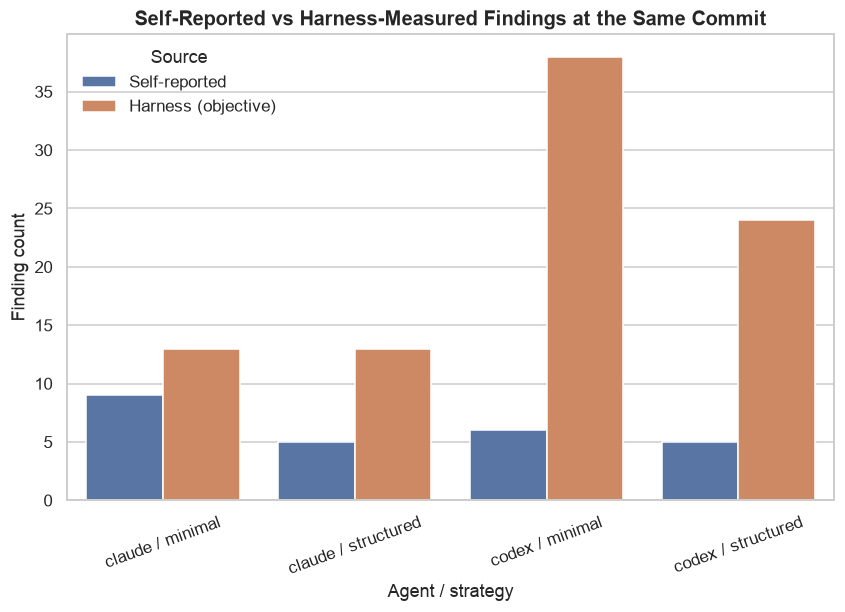

In [25]:
review_runs_path = DATA_DIR / "review_runs.csv"
review_runs = pd.read_csv(review_runs_path) if review_runs_path.exists() else pd.DataFrame()

if review_runs.empty:
    print("No T5 reviews in this dataset yet.")
else:
    ground_truth = pd.read_csv(DERIVED_DIR / "review_ground_truth.csv")
    overlap = pd.read_csv(DERIVED_DIR / "review_location_overlap.csv")

    display(ground_truth[[
        "session_id", "agent", "strategy", "review_status", "n_findings",
        "harness_findings_at_t3", "blind_spot", "under_reported",
    ]])

    comparison = ground_truth.rename(
        columns={"n_findings": "Self-reported", "harness_findings_at_t3": "Harness (objective)"}
    )
    comparison["condition"] = comparison["agent"] + " / " + comparison["strategy"]
    comparison_long = comparison.melt(
        id_vars="condition", value_vars=["Self-reported", "Harness (objective)"],
        var_name="source", value_name="finding_count",
    )
    charts.grouped_bar(
        comparison_long, x="condition", y="finding_count", hue="source",
        title="Self-Reported vs Harness-Measured Findings at the Same Commit",
        xlabel="Agent / strategy", ylabel="Finding count",
        legend_title="Source",
    )

    display(overlap)

---
## Appendix — Agent Execution Cost

Not an architecture-integrity result: how expensive/slow each agent run
was. Useful for the experimental-setup / cost section of the paper, not
Results.

One row per `(agent, prompt strategy, task)` — 16 runs total in this
dataset, no repeats to aggregate, so this is a table rather than a
distribution chart. Turn count is omitted: Codex CLI only ever reports one
top-level turn per run (`turn.started`/`turn.completed`), unlike the
Claude Agent SDK's per-message `num_turns`, so the two agents' turn counts
aren't comparable.

`cost_usd` is the Claude Agent SDK's own `total_cost_usd` for Claude rows.
Codex's CLI never reports a cost — only token counts — so Codex `cost_usd`
is **estimated** from `execution.json`'s `usage` block using the
gpt-5.3-codex pricing tier (USD / 1M tokens): input \$1.75, cached input
\$0.175, output \$14.00. See `estimate_codex_cost_usd()` in
[`src/ingest.py`](../src/ingest.py) for the exact formula and its
caveats; `cost_basis` below flags which rows are reported vs. estimated.

In [26]:
task_completion = pd.read_csv(DATA_DIR / "task_completion.csv")

cost_table = (
    task_completion
    .sort_values(["agent", "strategy", "task_order"])
    .rename(columns={"strategy": "prompt"})
    .assign(duration_min=lambda d: (d["duration_seconds"] / 60).round(2))
    [[
        "agent", "prompt", "task_id", "duration_seconds", "duration_min",
        "tokens_input_fresh", "tokens_input_cached", "tokens_output",
        "cost_usd", "cost_basis",
    ]]
    .reset_index(drop=True)
)
print("Per-run duration, token usage, and cost (agent x prompt x task):")
display(cost_table)

totals = (
    cost_table.groupby(["agent", "prompt"], as_index=False)
    .agg(
        n_tasks=("task_id", "count"),
        duration_seconds=("duration_seconds", "sum"),
        cost_usd=("cost_usd", "sum"),
    )
)
totals["duration_min"] = (totals["duration_seconds"] / 60).round(2)
print("\nTotals across all tasks in this dataset (T1+T2+T3+T5), per agent/prompt:")
display(totals[["agent", "prompt", "n_tasks", "duration_seconds", "duration_min", "cost_usd"]])

n_estimated = int((cost_table["cost_basis"] != "reported").sum())
if n_estimated:
    print(
        f"\n{n_estimated}/{len(cost_table)} rows use an estimated cost "
        "(cost_basis != 'reported') — see the markdown note above for the pricing used."
    )

Per-run duration, token usage, and cost (agent x prompt x task):


,agent,prompt,task_id,duration_seconds,duration_min,tokens_input_fresh,tokens_input_cached,tokens_output,cost_usd,cost_basis
0,claude,minimal,T1,1209.585,20.16,127,13102411,55106,5.426751,reported
1,claude,minimal,T2,1531.043,25.52,2463,8840283,93877,5.156441,reported
2,claude,minimal,T3,1318.183,21.97,143,14620847,49471,5.833305,reported
3,claude,minimal,T4,261.695,4.36,3761,580683,10639,0.745627,reported
4,claude,structured,T1,1372.780,22.88,134,14912922,67422,6.529676,reported
5,claude,structured,T2,1585.399,26.42,1438,9311361,78835,5.093242,reported
6,claude,structured,T3,1389.020,23.15,334,9103603,76585,4.812813,reported
7,claude,structured,T4,272.619,4.54,1060,724768,13012,0.875068,reported
8,codex,minimal,T1,572.936,9.55,267626,8254720,45018,2.543173,estimated_gpt-5.3-codex_pricing
9,codex,minimal,T2,774.683,12.91,407311,13082624,79294,4.112369,estimated_gpt-5.3-codex_pricing



Totals across all tasks in this dataset (T1+T2+T3+T5), per agent/prompt:


,agent,prompt,n_tasks,duration_seconds,duration_min,cost_usd
0,claude,minimal,4,4320.506,72.01,17.162124
1,claude,structured,4,4619.818,77.00,17.310800
2,codex,minimal,4,2288.570,38.14,11.138477
3,codex,structured,4,2430.474,40.51,12.421080



8/16 rows use an estimated cost (cost_basis != 'reported') — see the markdown note above for the pricing used.
